In [1]:
%load_ext autoreload
%autoreload 2

import pipeline
import networkx as nx
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import count
import time
import pickle
import shutil
import sys
import itertools
from collections import defaultdict
import geopandas as gpd
from tqdm.auto import tqdm
from libpysal.weights import Queen
import esda
import glob, os, re
from scipy.stats import ks_2samp
import math
from scipy.stats import wasserstein_distance
from haversine import haversine_vector

import plotly.io as pio
pio.renderers.default = "notebook"

seed = 21
interval = '24'
agg = True

if agg:
    if interval == "6":
        fpath = Path('data/agg/DEP_NET_GEOTAX11_14460_20190101_20191231_Tc6_Ts1.csv.gz')
        save_dir = Path(f'data/agg/tests/seed{seed}')
    elif interval == '24':
        fpath = Path('data/agg/DEP_NET_GEOTAX11_14460_20190101_20191231_Tc24_Ts1.csv.gz')
        save_dir = Path(f'data/agg/tests/seed{seed}')
    else:
        print("Invalid time range (must be 24 or 6)")
else:
    if interval == "6":
        fpath = Path('data/poi_level/6h/thresholded_networks/0_network.txt')
        save_dir = Path(f'data/poi_level/6h/tests/seed{seed}')
        data = Path('data/poi_level/depnet_undirected.gz')
    elif interval == '24':
        fpath = Path('data/poi_level/24h/0_network_24h.txt')
        save_dir = Path(f'data/poi_level/24h/tests/seed{seed}')
        data = Path('data/poi_level/24h/depnet_undirected_24h.gz')
    else:
        print("Invalid time range (must be 24 or 6)")

save_dir.mkdir(parents=True, exist_ok=True)

print(f"Interval: {interval} hrs | agg: {agg} | Seed: {seed}")

Interval: 24 hrs | agg: True | Seed: 21


In [2]:
_dtypes = {
    'NODE_A': 'category', 'NODE_B': 'category',
    'N_COVISITS': 'float32', 'DIST_KM_MIN': 'float32',
    'DIST_KM_MEAN': 'float32', 'N_UIDS_A': 'float32',
    'N_POIS_A': 'float32', 'N_VISITS_A': 'float32',
    'N_UIDS_B': 'float32', 'N_POIS_B': 'float32', 
    'N_VISITS_B': 'float32', 'DEP': 'float32'
}
df = pd.read_csv(fpath, dtype=_dtypes)

### Mapping POI coords to nodes manually

In [3]:
poi_path = Path('data/poi_level/24h/DEP_NET_UNDIRECT_14460_20190101_20191231_Tc24_Ts1.csv.gz')
poi_df = pd.read_csv(poi_path)
poi_df['GEOID_ORIGIN'] = poi_df['GEOID_ORIGIN'].astype(str).str.zfill(12)
poi_df['GEOID_DESTINATION'] = poi_df['GEOID_DESTINATION'].astype(str).str.zfill(12)
poi_df.info()
poi_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 15132068 entries, 0 to 15132067
Data columns (total 17 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ORIGIN                str    
 1   DESTINATION           str    
 2   TAXONOMY_ORIGIN       str    
 3   TAXONOMY_DESTINATION  str    
 4   GEOID_ORIGIN          str    
 5   GEOID_DESTINATION     str    
 6   LAT_ORIGIN            float64
 7   LNG_ORIGIN            float64
 8   LAT_DESTINATION       float64
 9   LNG_DESTINATION       float64
 10  DIST_KM               float64
 11  N_COVISITS            int64  
 12  N_UIDS_ORIGIN         int64  
 13  N_VISITS_ORIGIN       int64  
 14  N_UIDS_DESTINATION    float64
 15  N_VISITS_DESTINATION  float64
 16  DEP                   float64
dtypes: float64(8), int64(3), str(6)
memory usage: 1.9 GB


,ORIGIN,DESTINATION,TAXONOMY_ORIGIN,TAXONOMY_DESTINATION,GEOID_ORIGIN,GEOID_DESTINATION,LAT_ORIGIN,LNG_ORIGIN,LAT_DESTINATION,LNG_DESTINATION,DIST_KM,N_COVISITS,N_UIDS_ORIGIN,N_VISITS_ORIGIN,N_UIDS_DESTINATION,N_VISITS_DESTINATION,DEP
0,222-223@5q6-29r-kmk,zzw-224@62j-sj9-8vz,Transportation,Shopping,250173336003,250173501031,42.517396,-71.144118,42.394258,-71.082601,14.592806,1,1589,3829,8312.0,13615.0,0.000000
1,222-222@62j-scr-rhq,222-224@62k-r82-nt9,Grocery,Food,250173613005,250173215001,42.478754,-71.344742,42.361742,-71.559601,21.916887,1,87,284,110.0,916.0,0.000004
2,224-227@62k-26r-6p9,zzy-224@62k-2gp-94v,Shopping,Shopping,250235301002,250235091011,41.950962,-70.687764,41.969584,-70.715862,3.112136,2,1006,1561,902.0,1133.0,0.000001
3,22g-22b@62j-shv-8qf,329b4b7ea82e4ee7ed3c7ba6,Sports,Public Administration,250173742001,250173672003,42.321279,-71.207327,42.351266,-71.306533,8.809719,2,446,865,986.0,2351.0,0.000001
4,222-222@62j-pfh-syv,224-226@62j-psd-j35,Food,Personal Care Service,250092221001,250092151024,42.653407,-70.805771,42.611179,-70.875639,7.397153,3,1786,3015,204.0,336.0,0.000003


In [4]:
# filter to tract
geoid_cols = poi_df.columns[poi_df.columns.str.contains('GEOID')]
poi_df[geoid_cols] = poi_df[geoid_cols].astype(str).apply(lambda x: x.str[:-1])

poi_df['ORIGIN_NODE'] = poi_df['GEOID_ORIGIN'] + '_' + poi_df['TAXONOMY_ORIGIN']
poi_df['DESTINATION_NODE'] = poi_df['GEOID_DESTINATION'] + '_' + poi_df['TAXONOMY_DESTINATION']

# extracting origins and destinations and dropping duplicates
origins = poi_df[[
    'ORIGIN', 'LAT_ORIGIN', 'LNG_ORIGIN', 'ORIGIN_NODE', 
    'GEOID_ORIGIN', 'TAXONOMY_ORIGIN'
]].drop_duplicates().rename(
    columns={
        'ORIGIN': 'POI', 
        'ORIGIN_NODE': 'NODE',
        'LAT_ORIGIN': 'LAT',
        'LNG_ORIGIN': 'LNG',
        'GEOID_ORIGIN': 'GEOID',
        'TAXONOMY_ORIGIN': 'TAXONOMY'
    }
)
destinations = poi_df[[
    'DESTINATION', 'LAT_DESTINATION', 'LNG_DESTINATION', 'DESTINATION_NODE', 
    'GEOID_DESTINATION', 'TAXONOMY_DESTINATION'
]].drop_duplicates().rename(
    columns={
        'DESTINATION': 'POI', 
        'DESTINATION_NODE': 'NODE',
        'LAT_DESTINATION': 'LAT',
        'LNG_DESTINATION': 'LNG',
        'GEOID_DESTINATION': 'GEOID',
        'TAXONOMY_DESTINATION': 'TAXONOMY'
    }
)
poi_df = pd.concat([origins, destinations], ignore_index=True).drop_duplicates()
node_decoder = poi_df.groupby('NODE')['POI'].apply(list).to_dict()

# add col for tract
poi_df['TRACT'] = poi_df['GEOID'].str[:11]

In [ ]:

poi_df.groupby('POI')['GEOID'].nunique().value_counts()

GEOID
1    115967
Name: count, dtype: int64

In [ ]:
# check: number of POIs that failed to dedupe + number of POIs mapping to more than one node
duplicate_count = poi_df.duplicated(subset=['POI']).sum()
node_counts = poi_df.groupby('POI')['NODE'].nunique()
problem_pois = node_counts[node_counts > 1]
print(f"There are {duplicate_count} duplicate POI rows and {len(problem_pois)} POIs mapped to multiple nodes")
print(f'{len(poi_df)} total rows')

# diagnostics
dupes_only = poi_df[poi_df.duplicated(subset=['POI'], keep=False)]
unique_counts = dupes_only.groupby('POI').nunique()
unique_counts = dupes_only.groupby('POI').nunique()
mismatched_cols = unique_counts.columns[(unique_counts > 1).any()].tolist()
print(f"The columns causing the duplicates are: {mismatched_cols}")
breakdown = (unique_counts > 1).sum()
print("Number of POIs affected by mismatches in:")
print(breakdown)

There are 0 duplicate POI rows and 0 POIs mapped to multiple nodes
115967 total rows
The columns causing the duplicates are: []
Number of POIs affected by mismatches in:
LAT         0
LNG         0
NODE        0
GEOID       0
TAXONOMY    0
dtype: int64


In [ ]:
nodes_a = df[['NODE_A', 'N_POIS_A']].rename(
    columns={'NODE_A': 'NODE', 'N_POIS_A': 'POI_COUNT'}
)

# 2. Extract the nodes and counts from the "B" side of the edge list
nodes_b = df[['NODE_B', 'N_POIS_B']].rename(
    columns={'NODE_B': 'NODE', 'N_POIS_B': 'POI_COUNT'}
)

# 3. Combine them and drop duplicates to get ONE true count per node
truth_df = pd.concat([nodes_a, nodes_b]).drop_duplicates(subset=['NODE'])

# Convert it into a Pandas Series for easy comparison later
truth_counts = truth_df.set_index('NODE')['POI_COUNT']

# 1. Total POI Check: Do you even have the same amount of POIs?
print("Total POIs in your dataset:", len(poi_df['POI'].unique()))
print("Total POIs in their network:", truth_counts.sum())
print("-" * 30)

# 2. Node Name Match Check: Do the node strings actually match?
your_nodes = set(poi_df['NODE'].unique())
their_nodes = set(truth_counts.index.unique())

overlap = your_nodes.intersection(their_nodes)
print(f"You have {len(your_nodes)} unique nodes.")
print(f"They have {len(their_nodes)} unique nodes.")
print(f"Exactly {len(overlap)} nodes match perfectly.")
print("-" * 30)

# 3. Visual Check: Print one node from each to see the difference
print("Example Node (Yours):", list(your_nodes)[0] if your_nodes else "None")
print("Example Node (Theirs):", list(their_nodes)[0] if their_nodes else "None")

Total POIs in your dataset: 115967
Total POIs in their network: 116417.0
------------------------------
You have 15136 unique nodes.
They have 15136 unique nodes.
Exactly 15136 nodes match perfectly.
------------------------------
Example Node (Yours): 25017370102_Financial Service
Example Node (Theirs): 25017370102_Financial Service


add two new columns to df

1. map all the POIs to their proper buckets 
2. if the tract columns are too duplicated, first filter to the nodes that exist in the agg network
3. collect their coords into (n_pois, 2) arrays
4. somehow get an entry to add to the column only if the corresponding node is the right one
5. to figure out how he calculated distance try calculating it in both ways for like 5 or so ones that already exist and see which one matches

In [5]:
# --- apply to agg df ---

# extract unique nodes
buckets = df[['NODE_A', 'NODE_B']].stack().drop_duplicates().reset_index(drop=True).to_frame(name='NODE_ID')
buckets[['TRACT', 'TAXONOMY']] = buckets['NODE_ID'].str.split('_', expand=True)

# merge with poi_df
node_to_poi = pd.merge(buckets, poi_df, on=['TRACT', 'TAXONOMY'], how='left')

# group by agg node, zip lat/lng into coordinate pairs, and convert to tuple of tuples
coord_arrays = node_to_poi.groupby('NODE_ID').apply(lambda x: tuple(map(tuple, x[['LAT', 'LNG']].to_numpy())))

# add back to agg df as attr
df['NODE_A_COORDS'] = df['NODE_A'].astype(object).map(coord_arrays)
df['NODE_B_COORDS'] = df['NODE_B'].astype(object).map(coord_arrays)

# convert back to arrays
df['NODE_A_COORDS'] = df['NODE_A_COORDS'].apply(np.array)
df['NODE_B_COORDS'] = df['NODE_B_COORDS'].apply(np.array)

# check if any buckets with no coords (shouldn't be possible)
a_empty = (~df['NODE_A_COORDS'].apply(lambda x: isinstance(x, np.ndarray))).sum()
b_empty = (~df['NODE_B_COORDS'].apply(lambda x: isinstance(x, np.ndarray))).sum()
num_empty = a_empty + b_empty
print(f'# empty: {num_empty}')

# empty: 0


In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5229044 entries, 0 to 5229043
Data columns (total 15 columns):
 #   Column         Dtype   
---  ------         -----   
 0   NODE_A         category
 1   NODE_B         category
 2   N_COVISITS     float32 
 3   DIST_KM_MIN    float64 
 4   DIST_KM_MEAN   float64 
 5   SELF_LOOP      bool    
 6   N_UIDS_A       float32 
 7   N_POIS_A       float32 
 8   N_VISITS_A     float32 
 9   N_UIDS_B       float32 
 10  N_POIS_B       float32 
 11  N_VISITS_B     float32 
 12  DEP            float32 
 13  NODE_A_COORDS  object  
 14  NODE_B_COORDS  object  
dtypes: bool(1), category(2), float32(8), float64(2), object(2)
memory usage: 345.3+ MB


In [6]:
# recalculate DIST_KM_MEAN as the mean haversine distance across all coord
# combinations between endpoints

def avg_pairwise_dist(coords_a, coords_b):
    if coords_a.size == 0 or coords_b.size == 0:
        return np.nan
    return haversine_vector(coords_a, coords_b, comb=True).mean()

df['DIST_KM_MEAN'] = df.apply(
    lambda row: avg_pairwise_dist(row['NODE_A_COORDS'], row['NODE_B_COORDS']), axis=1
)

In [7]:
# save new agg edgelist
with open('data/agg/geotax_complete_24h.pkl', 'wb') as f:
    pickle.dump(df, f)

### Agg Network Examination

In [ ]:
_dtypes = {
    'NODE_A': 'category', 'NODE_B': 'category',
    'N_COVISITS': 'float32', 'DIST_KM_MIN': 'float32',
    'DIST_KM_MEAN': 'float32', 'N_UIDS_A': 'float32',
    'N_POIS_A': 'float32', 'N_VISITS_A': 'float32',
    'N_UIDS_B': 'float32', 'N_POIS_B': 'float32', 
    'N_VISITS_B': 'float32', 'DEP': 'float32'
}
df = pd.read_csv(fpath, dtypes=_dtypes)

print(df.info())
count = ((df['DEP'] != 0) & (df['DEP'].notna())).sum()
print(f'{count}/{df.shape[0]}')
df.head(10)

['NODE_A', 'NODE_B', 'N_COVISITS', 'DIST_KM_MIN', 'DIST_KM_MEAN', 'SELF_LOOP', 'N_UIDS_A', 'N_POIS_A', 'N_VISITS_A', 'N_UIDS_B', 'N_POIS_B', 'N_VISITS_B', 'DEP']
662098/5229044


,NODE_A,NODE_B,N_COVISITS,DIST_KM_MIN,DIST_KM_MEAN,SELF_LOOP,N_UIDS_A,N_POIS_A,N_VISITS_A,N_UIDS_B,N_POIS_B,N_VISITS_B,DEP
0,25017351500_Food,25021404302_Financial Service,1,18.950987,18.950987,False,8067,15,19066,3124,15,8709,0.000000
1,25017331102_Industry,25017383700_Personal Care Service,39,31.381830,31.758977,False,3696,38,24499,2057,8,19001,0.000000
2,25021418002_Grocery,25021419300_Transportation,8,1.042693,1.089788,False,4679,10,12310,427,9,1403,0.000000
3,25009250100_Food,25025170300_Transportation,2,33.418857,33.418857,False,7823,50,24417,6257,38,19602,0.000000
4,25017373400_Financial Service,25017373400_School,214,0.040694,0.065415,False,2610,13,8619,633,2,1926,0.000013
5,25021420302_Industry,25021456200_Industry,61,1.133780,1.346927,False,4097,5,6600,1694,20,10832,0.000001
6,25025020101_Shopping,25025070101_Entertainment,19,0.471360,0.842894,False,3123,51,6184,17554,47,37635,0.000000
7,25021419200_College,25021422502_Automotive Service,38,3.817854,3.819596,False,815,4,5211,811,10,2174,0.000003
8,25025010203_Arts / Museum,25025010405_College,54,0.401692,0.867843,False,6153,3,10959,13573,161,194033,0.000000
9,25017333100_Sports,25025091900_Transportation,1,20.055539,20.055539,False,1028,6,3208,1311,8,3333,0.000000


N_COVISITS
1.0       2951168
2.0        833313
3.0        382528
4.0        221720
5.0        145365
           ...   
1619.0          1
1256.0          1
1175.0          1
1414.0          1
1265.0          1
Name: count, Length: 2009, dtype: int64
0 nulls

DEP descriptive stats
count    5.229044e+06
mean     3.363632e-07
std      6.896293e-06
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      8.403000e-03
Name: DEP, dtype: float64
0 nulls


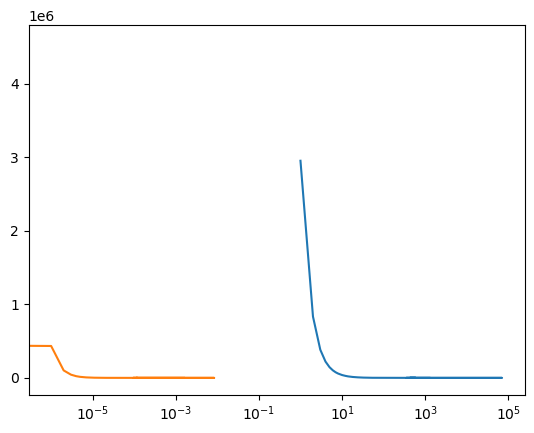

In [16]:
plt.semilogx(df['N_COVISITS'].value_counts())
print(df['N_COVISITS'].value_counts())
print(f'{df["N_COVISITS"].isna().sum()} nulls')

print('\nDEP descriptive stats')
plt.semilogx(df['DEP'].value_counts())
print(df['DEP'].describe())
print(f'{df["DEP"].isna().sum()} nulls')

In [2]:
G, train_non_edges, test_pos_edges, test_non_edges = pipeline.prepare_data(fpath, test_frac=0.25, controlled=False, meta=True)

Nodes: 15831
Edges: 5288458


sampling non-edges:   0%|          | 0/1322114 [00:00<?, ?edge/s]

sampling non-edges:   0%|          | 0/3966344 [00:00<?, ?edge/s]

Wrote training graph: 15831 nodes, 3966344 edges


In [3]:
# checking unmatched distribution of weak vs strong class

trainfile = 'data/train.txt'
G_train = nx.read_edgelist(
    trainfile, data=[('weight', float)], delimiter='\t')
train_pos_edges = [tuple(sorted(e)) for e in G_train.edges()]

def _dep(edges, keep):
    return np.array([G[u][v]['DEP'] for u, v in edges],
                    dtype=np.float64)[keep]

keep_train_pos = list(range(len(train_pos_edges)))
keep_test_pos = list(range(len(test_pos_edges)))

# save original index order to match back to G
edges_train = np.array(train_pos_edges, dtype=object)
edges_test = np.array(test_pos_edges, dtype=object)
edges_all = np.concatenate((edges_train, edges_test))

# deps

dep_train = _dep(train_pos_edges, keep_train_pos)
dep_test = _dep(test_pos_edges, keep_test_pos)
dep_all = np.concatenate((dep_train, dep_test))

dep_train, edges_train = dep_train[dep_train > 0], edges_train[dep_train > 0]
dep_test, edges_test = dep_test[dep_test > 0], edges_test[dep_test > 0]
dep_all, edges_all = dep_all[dep_all > 0], edges_all[dep_all > 0]

# actual sorted edges plus indices of sorted edges for later lookup
train_order, test_order, all_order = np.argsort(dep_train), np.argsort(dep_test), np.argsort(dep_all)
dep_train, edges_train = dep_train[train_order], edges_train[train_order]
dep_test, edges_test = dep_test[test_order], edges_test[test_order]
dep_all, edges_all = dep_all[all_order], edges_all[all_order]

# fit on train only to match pipeline behavior
thr = np.quantile(dep_train, 0.5)

train_mask = dep_train > thr
dep_train_strong, edges_train_strong = dep_train[train_mask], edges_train[train_mask]
dep_train_weak, edges_train_weak = dep_train[~train_mask], edges_train[~train_mask]

test_mask = dep_test > thr
dep_test_strong, edges_test_strong = dep_test[test_mask], edges_test[test_mask]
dep_test_weak, edges_test_weak = dep_test[~test_mask], edges_test[~test_mask]

all_mask = dep_all > thr
dep_all_strong, edges_all_strong = dep_all[all_mask], edges_all[all_mask]
dep_all_weak, edges_all_weak = dep_all[~all_mask], edges_all[~all_mask]

# distances

def _dist(edges):
    return np.array([G[u][v]['DIST_KM_MEAN'] for u, v in edges], dtype=np.float32)

dist_train_strong = _dist(edges_train_strong)
dist_train_weak = _dist(edges_train_weak)
dist_train = _dist(edges_train)
dist_test_strong = _dist(edges_test_strong)
dist_test_weak = _dist(edges_test_weak)
dist_test = _dist(edges_test)
dist_all_strong = _dist(edges_all_strong)
dist_all_weak = _dist(edges_all_weak)
dist_all = _dist(edges_all)


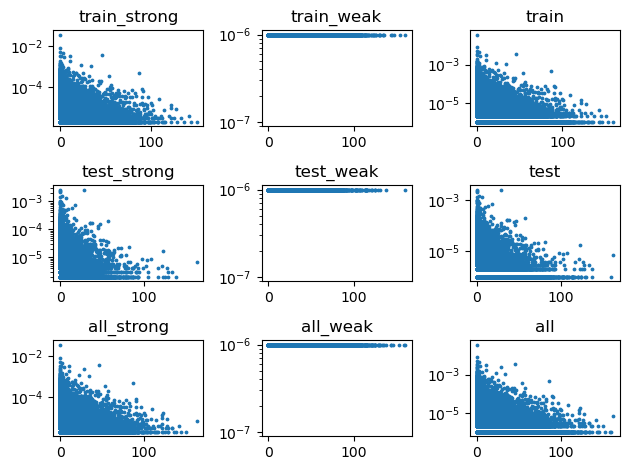

In [16]:
# plot dep against distance

fig, ax = plt.subplots(3, 3)

order = [
    (dist_train_strong, dep_train_strong),
    (dist_train_weak, dep_train_weak), 
    (dist_train, dep_train),
    (dist_test_strong, dep_test_strong), 
    (dist_test_weak, dep_test_weak), 
    (dist_test, dep_test),
    (dist_all_strong, dep_all_strong), 
    (dist_all_weak, dep_all_weak), 
    (dist_all, dep_all)
]
titles = ['train_strong', 'train_weak', 'train',
         'test_strong', 'test_weak', 'test',
         'all_strong', 'all_weak', 'all']

cur_row_idx = 0
cur_col_idx = 0
for i, (dist_class, dep_class) in enumerate(order):
    ax[cur_row_idx, cur_col_idx].scatter(dist_class, dep_class, s=3)
    ax[cur_row_idx, cur_col_idx].set_title(titles[i])
    # ax[cur_row_idx, cur_col_idx].set_xscale('log')
    ax[cur_row_idx, cur_col_idx].set_yscale('log')
    if i in [2, 5]:
        cur_col_idx = 0
        cur_row_idx += 1
    else:
        cur_col_idx += 1

plt.tight_layout()
plt.savefig('figures/agg/temp/strength_dep_dist_logy.png')

In [4]:
# isolate distance-controlling to see its behavior

def _dist_matched_idx(dep, dist, thr):
    # same log bins as the link version, then keep min(#strong, #weak)
    strong = dep > thr
    if dist.max() > 0.01:
        edges_b = np.concatenate(
            ([0], np.geomspace(0.01, dist.max(), 50)))
    else:
        edges_b = np.linspace(0, dist.max() + 1e-5, 50)
    # indexes the bin that each edge falls into
    b = np.digitize(dist, edges_b)
    keep = []
    for bin_id in np.unique(b):
        # strong and weak within bin (returns indices)
        in_bin = np.where(b == bin_id)[0]
        s = in_bin[strong[in_bin]]
        w = in_bin[~strong[in_bin]]
        k = min(len(s), len(w))
        if k == 0:
            continue
        # select k random samples from within-bin subsets w/o replacement
        # (smaller one technically just gets copied but its fast enough
        # that the redundancy doesn't matter)
        keep.extend(np.random.choice(s, k, replace=False))
        keep.extend(np.random.choice(w, k, replace=False))
    return np.sort(np.array(keep, dtype=int))

idx_tr = _dist_matched_idx(dep_train, dist_train, thr)
idx_te = _dist_matched_idx(dep_test, dist_test, thr)

# filter dep/edges/dist down to the matched subset
dep_train_matched, edges_train_matched, dist_train_matched = (
    dep_train[idx_tr], edges_train[idx_tr], dist_train[idx_tr])
dep_test_matched, edges_test_matched, dist_test_matched = (
    dep_test[idx_te], edges_test[idx_te], dist_test[idx_te])

y_str_train_matched = (dep_train_matched > thr).astype(int)
y_str_test_matched = (dep_test_matched > thr).astype(int)

print(f"Distance-matched strength set: "
      f"train {len(idx_tr)}/{len(dep_train)}, "
      f"test {len(idx_te)}/{len(dep_test)} edges kept")
if len(np.unique(y_str_test_matched)) < 2 or len(np.unique(y_str_train_matched)) < 2:
    print("Warning: a strength class vanished after distance "
          "matching — cannot score.")

Distance-matched strength set: train 314420/523964, test 104900/174356 edges kept


In [9]:
# confirm the floor pileup in nonzero DEP

floor_val = np.float32(1e-6)
n_at_floor = (dep_all == floor_val).sum()
print(f"Nonzero DEP edges: {len(dep_all)}")
print(f"Edges exactly at floor ({floor_val}): {n_at_floor} ({n_at_floor / len(dep_all):.2%})")

# most common nonzero DEP values
vals, counts = np.unique(dep_all, return_counts=True)
order = np.argsort(counts)[::-1]
print("\nTop 10 most common nonzero DEP values:")
for v, c in zip(vals[order][:10], counts[order][:10]):
    print(f"  {v:.6e} : {c} edges ({c / len(dep_all):.2%})")

# quantile sweep to see where the distribution escapes the floor pileup
print("\nQuantile sweep:")
for q in [0.5, 0.7, 0.8, 0.87, 0.9, 0.95, 0.99]:
    print(f"  q={q:.2f} -> {np.quantile(dep_all, q):.6e}")

Nonzero DEP edges: 698320
Edges exactly at floor (9.999999974752427e-07): 451068 (64.59%)

Top 10 most common nonzero DEP values:
  1.000000e-06 : 451068 edges (64.59%)
  2.000000e-06 : 107247 edges (15.36%)
  3.000000e-06 : 46714 edges (6.69%)
  4.000000e-06 : 25130 edges (3.60%)
  5.000000e-06 : 15469 edges (2.22%)
  6.000000e-06 : 10132 edges (1.45%)
  7.000000e-06 : 7260 edges (1.04%)
  8.000000e-06 : 5232 edges (0.75%)
  9.000000e-06 : 4122 edges (0.59%)
  1.000000e-05 : 3267 edges (0.47%)

Quantile sweep:
  q=0.50 -> 1.000000e-06
  q=0.70 -> 2.000000e-06
  q=0.80 -> 3.000000e-06
  q=0.87 -> 4.000000e-06
  q=0.90 -> 4.000000e-06
  q=0.95 -> 8.000000e-06
  q=0.99 -> 2.500000e-05


In [ ]:
# bugfix pipeline

G = pipeline.load(fpath)
dep_edges = sum(1 for _, _, d in G.edges(data=True) if d.get('DEP', 0) != 0)
total_edges = G.number_of_edges()

print(f"{dep_edges}/{total_edges}")

### Thresholded Network Build (POI-level)

In [ ]:
# --- dependency distribution ---

# reading in + dealing with missing values
df = pd.read_csv(data)
df['DEP'] = pd.to_numeric(df['DEP'], errors='coerce')
df = df.dropna(subset=['DEP'])

# sampling for performance
plot_data = df['DEP'].sample(100000)
print(plot_data.describe())

sns.displot(plot_data, bins=30, kde=True, stat='probability', log_scale=True)
plt.margins(x=0)

# --- num removed vs binned values ---

dep_nonzero = df.loc[df['DEP'] > 0, 'DEP'].sort_values().values
total_edges = len(df)
zero_edges = total_edges - len(dep_nonzero)

print(f"Total edges: {total_edges}")
print(f"Zero-DEP edges: {zero_edges}")
print(f"Nonzero DEP range: [{dep_nonzero.min():.2e}, {dep_nonzero.max():.2e}]")

# log-spaced bins across the nonzero DEP range
bins = np.logspace(np.log10(dep_nonzero.min()), np.log10(dep_nonzero.max()), 200)

# for each threshold, edges retained = nonzero edges with DEP >= threshold
edges_retained = len(dep_nonzero) - np.searchsorted(dep_nonzero, bins, side='left')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(bins, edges_retained)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('DEP threshold')
ax.set_ylabel('Number of edges retained')
ax.set_title('Edges retained vs DEP threshold')

ax.axhline(y=1_000_000, color='r', linestyle='--', label='1M edges')
ax.axhline(y=10_000, color='orange', linestyle='--', label='10k edges')
ax.legend()
plt.show()

# find approximate thresholds
vals = []
for target, label in [(1_000_000, 'DEP_low (~1M)'), (10_000, 'DEP_high (~10k)')]:
    idx = np.argmin(np.abs(edges_retained - target))
    vals.append(bins[idx])
    print(f"{label}: DEP â‰ˆ {bins[idx]:.6e}, edges retained = {edges_retained[idx]}")

DEP_low = vals[0]
DEP_high = vals[1]

In [ ]:
all = 0

# reloading df if needed
if 'df' not in globals():
    df = pd.read_csv(data)
    df['DEP'] = pd.to_numeric(df['DEP'], errors='coerce')
    df = df.dropna(subset=['DEP'])

if all:
    # filtering
    DEP_range = df[df['DEP'].between(DEP_low, DEP_high)]
    # calculating thresholds with bounded range
    quantiles = np.quantile(DEP_range['DEP'], [0.25, 0.5, 0.75])
    thresholds = np.concatenate([[DEP_low], quantiles, [DEP_high]])

    # creating networks with original uncapped df
    for i, threshold in zip(count(0, 0.25), thresholds):
        # filter
        thresholded_df = df[df['DEP'] >= threshold]
        
        # save df directly
        filepath = f'data/undir_trials/thresholded_networks/{i}_network.txt'
        thresholded_df.to_csv(filepath, sep=' ', index=False, header=False)
        
        print(f"Saved {filepath} with {len(thresholded_df)} edges")
else:
    thresholded_df = df[df['DEP'] >= DEP_low]
    filepath = f'data/undir_trials/24h/network.txt'
    thresholded_df.to_csv(filepath, sep=' ', index=False, header=False)
    print(f"Saved {filepath} with {len(thresholded_df)} edges")